|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Weight inits and investigations<h1>|
|<h2>Lecture:</h2>|<h1><b>A surprising demonstration of weight initializations<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import and process the data

In [2]:
# download MNIST dataset
output_dir = 'sample_data'
mnist = datasets.MNIST(root='sample_data', download=True)

# extract labels (number IDs) and data
labels = mnist.targets.numpy()
data = mnist.data.numpy().reshape(mnist.data.shape[0], -1)  # flatten to 2D

# normalize the data to a range of [0 1]
dataNorm = data / np.max(data)

print(labels.shape)
print(data.shape)

(60000,)
(60000, 784)


In [3]:
# Step 1: convert to tensor
dataT   = torch.tensor( dataNorm ).float()
labelsT = torch.tensor( labels ).long()

# Step 2: use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(dataT, labelsT, test_size=.1)

# Step 3: convert into PyTorch Datasets
train_data = torch.utils.data.TensorDataset(train_data,train_labels)
test_data  = torch.utils.data.TensorDataset(test_data,test_labels)

# Step 4: translate into dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

# Create the DL model

In [4]:
# create a class for the model
def createTheMNISTNet():

  class mnistNet(nn.Module):
    def __init__(self):
      super().__init__()

      ### input layer
      self.input = nn.Linear(784,64)

      ### hidden layer
      self.fc1 = nn.Linear(64,32)
      self.fc2 = nn.Linear(32,32)

      ### output layer
      self.output = nn.Linear(32,10)

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.fc1(x) )
      x = F.relu( self.fc2(x) )
      return self.output(x)
    
    @staticmethod
    @torch.no_grad()
    def accuracy(yHat: torch.Tensor, y: torch.Tensor) -> float:
      return torch.mean((torch.argmax(yHat,axis=1)==y).float()).detach().item()

  # create the model instance
  net = mnistNet()

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.01)

  return net,lossfun,optimizer

# Create a function that trains the model

In [5]:
def function2trainTheModel(net,lossfun,optimizer, numepochs:int=10):
  # initialize losses
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  testAcc   = []

  # loop over epochs
  for epochi in range(numepochs):

    # switch on train mode
    net.train()

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      batchAcc.append( 100*net.accuracy(yHat,y)  ) # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    net.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)

    # compare the following really long line of code to the training accuracy lines
    testAcc.append( 100*net.accuracy(yHat,y) )
  # end epochs

  # function output
  return trainAcc,testAcc,losses,net

# Run the model and show the results!

In [6]:
stds = np.logspace(-4,1,25)
final3TestAcc = np.zeros((len(stds)))

net,lossfun,optimizer = createTheMNISTNet()  # dummy net creation to eval number of trainbale parameters
total_params = sum(p.numel() for p in net.parameters() if p.requires_grad)

weights = np.zeros((len(stds), total_params))
for i, std in enumerate(stds):
    # Create the model
    net,lossfun,optimizer = createTheMNISTNet()

    # Initialize weights with given std
    for param in net.parameters():
        nn.init.normal_(param, mean=0.0, std=std)

    # Train the model
    trainAcc,testAcc,losses,net = function2trainTheModel(net,lossfun,optimizer,numepochs=10)
    final3TestAcc[i] = np.mean(testAcc[-3:])
    
    weights_flatten = np.array([])
    for p in net.named_parameters():
        weights_flatten = np.concatenate((weights_flatten, p[1].data.flatten().numpy()))
    weights[i,:] = weights_flatten

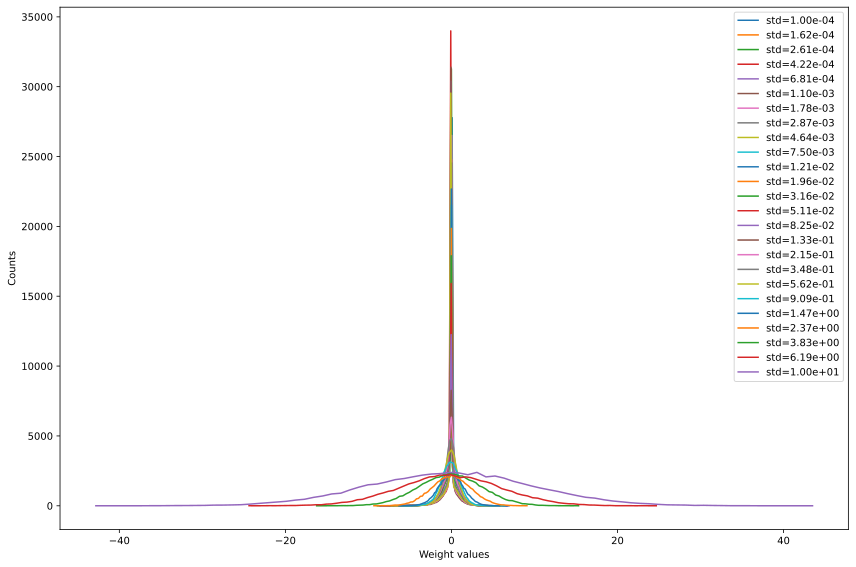

In [7]:
# Plot weights histograms and accuracies
fig = plt.figure(figsize=(12,8))
nbins = 80
for i, w_list in enumerate(weights):
    y,x = np.histogram(w_list,nbins)
    plt.plot((x[1:]+x[:-1])/2,y,label=f'std={stds[i]:.2e}')
    
plt.ylabel('Counts')
plt.legend(loc='best')
plt.xlabel('Weight values')

fig.tight_layout()
plt.show()

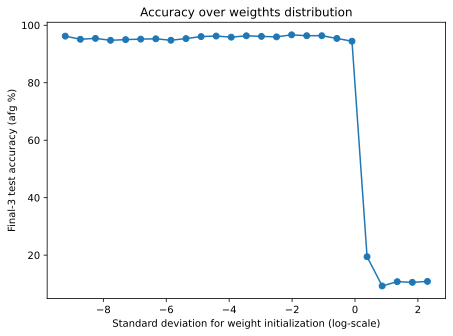

In [8]:
# plot the results
fig = plt.figure()
plt.plot(np.log(stds), final3TestAcc, 'o-')
plt.title('Accuracy over weigthts distribution')
plt.xlabel('Standard deviation for weight initialization (log-scale)')
plt.ylabel('Final-3 test accuracy (afg %)')
fig.tight_layout()
plt.show()

# Additional explorations

In [9]:
# 1) Are you sure we calculated the standard deviations correctly? Immediately after the code that initializes the weights,
#    write some more code that gets all of the weights (across all layers), compute the standard deviation, and then print
#    out the desired and actual standard deviations. Note that they won't correspond exactly, due to sampling variability.
#    Also note that because this is just a sanity check, you don't actually need to train the model; just verify that the
#    weights have been correctly calculated.
#
# 2) Here we used torch.randn to assign the weights. randn creates Gaussian random numbers with a mean of 0, and thus
#    the weights were initialized with both positive and negative values. Try running the experiment again using
#    torch.rand, which creates uniformly distributed numbers between 0 and 1.
#    NOTE: Specifying the standard deviation of a uniform distribution is slightly more involved compared to a normal
#    distribution. See https://math.stackexchange.com/a/140081 for instructions.
#